In [2]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import sklearn
from lib.readwav import *

In [3]:

%matplotlib widget
plt.close('all')

# Ciao


questo codice funziona benissimo per segnali con frequenze molto altre (sopra i 500Hz va che è una meraviglia)

ahimè, tra tutti i file .wav ce ne sono alcuni che hanno frequenze sui 100Hz o 200Hz e in questi casi il codice non riesce ad identificare correttamente le frequenze in generale.

esempi di buon funzionamento: note_1.wav, note_104.wav, note_2.wav

esempi di cattivo funzionamento: note_72.wav, note_238.wav

per i file per cui non va bene è perchè a frequenza bassa hanno periodo maggiore, quindi nel fare l'averging taglio fuori qualcosa di troppo, quindi aumentando funziona.
Per automattizzare questa selezione si potrebbe calcolare preventivamente il periodo del segnale e scegliere la dimensione della finestra in base a questo, in modo da avere sempre un numero sufficiente di periodi all'interno di ogni finestra.

In [57]:
# leggiamo un singolo file audio
rate, note = readwav('./wav_files/note_66.wav')
print('rate =', rate)
print('note =', note)

rate = 48000
note = [[      0       0]
 [      0       0]
 [      1       0]
 ...
 [ 171431 -313512]
 [ 129471 -258768]
 [  90904 -198780]]


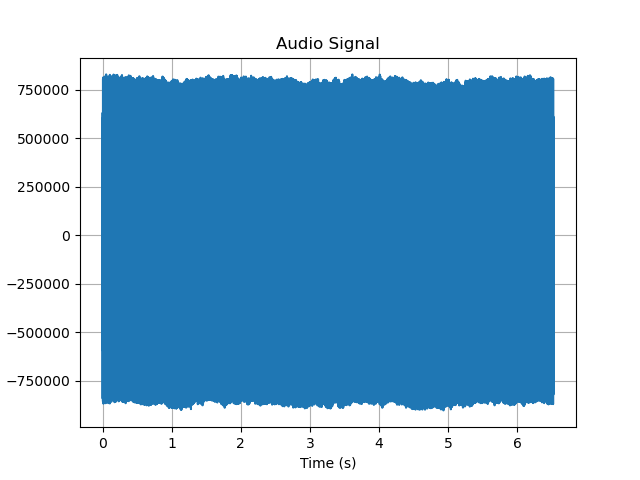

: 

In [ ]:
#togliamo il primo 25% del segnale e l'ultimo 10% e plotto mantenendo i secondi corretti
note = note[:, 0] # prendo solo un canale se il segnale è stereo

start = int(len(note) * 0.25)
end = int(len(note) * 0.9)
note = note[start:end]
time = np.arange(len(note)) / rate
plt.figure()
plt.plot(time, note)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Audio Signal')
plt.grid()
plt.show()

In [ ]:
# Implementiamo la finestra gaussiana da applicare al segnale, in modo da attenure l'attacco e il decadimento
def gaussian_window(signal, sigma):
    n = signal.shape[0]
    x = np.arange(n)
    center = 0.5 * n
    window = np.exp(-0.5 * ((x - center) / sigma) ** 2)
    return signal * window


# applichiamo la finestra gaussiana al segnale  (sigma deve dipendere da tempo finestra)
sigma = 10000  # puoi regolare questo parametro per ottenere l'effetto desiderato
note_windowed = gaussian_window(note, sigma)

# visualizzo segnale originale e sotto segnale con fnestra gaussiana
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(time, note)
plt.title('Segnale originale')
plt.subplot(2, 1, 2)
plt.plot(time, note_windowed)
plt.title('Segnale con finestra gaussiana')
plt.tight_layout()
plt.show()


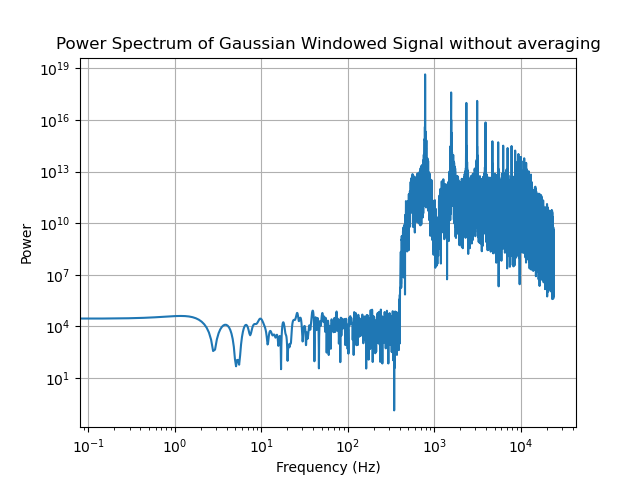

In [ ]:
# vediamo come sarebbe power spectrum della finestra gaussiana senza fare la media su più finestre
fft_gaussian = np.fft.rfft(note_windowed)
power_gaussian = np.abs(fft_gaussian) ** 2
frequencies = np.fft.rfftfreq(len(note_windowed), d=1/rate)
plt.figure()
plt.loglog(frequencies, power_gaussian)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('Power Spectrum of Gaussian Windowed Signal without averaging')
plt.grid()
plt.show()

In [ ]:
# controllo periodo file audio per impostare dimensione finestra
# calcolo periodo del file audio senza finestra gaussiana
# prendo note e prendo quando ripassa dallo zero
zero_crossings = np.where(np.diff(np.sign(note)))[0]
periods = np.diff(zero_crossings) / rate  # in secondi
average_period = np.mean(periods)

#calcolo frequenza come inverso del periodo
frequenza_preventiva = 1 / average_period
print('Frequenza oscillazione segnale stimata:', frequenza_preventiva, 'Hz')

Frequenza oscillazione segnale stimata: 1573.6337444168355 Hz


In [ ]:
window_size = 0

if frequenza_preventiva >= 500:
    window_size = 2048
else:
    window_size = 8192

#Divido il segnale in segmenti (finestre)
hop_size = 512     # passo di sovrapposizione
num_windows = (len(note) - window_size) // hop_size + 1

#Per ogni segmento, applico la finestra gaussiana e calcolo la rfft e poi la sua potenza (modulo quadro). Sommo tutti questi spettri di potenza e divido per il numero di segmenti.
power_spectra = []
for i in range(num_windows):
    start = i * hop_size
    end = start + window_size
    segment = note[start:end]
    
    # Applico la finestra gaussiana al segmento
    segment_windowed = gaussian_window(segment, 10000)
    
    # Calcolo la rfft e poi la sua potenza (modulo quadro)
    spectrum = np.fft.rfft(segment_windowed)
    power_spectrum = np.abs(spectrum) ** 2
    power_spectra.append(power_spectrum)

# Sommo tutti questi spettri di potenza e divido per il numero di segmenti
average_power_spectrum = np.mean(power_spectra, axis=0)


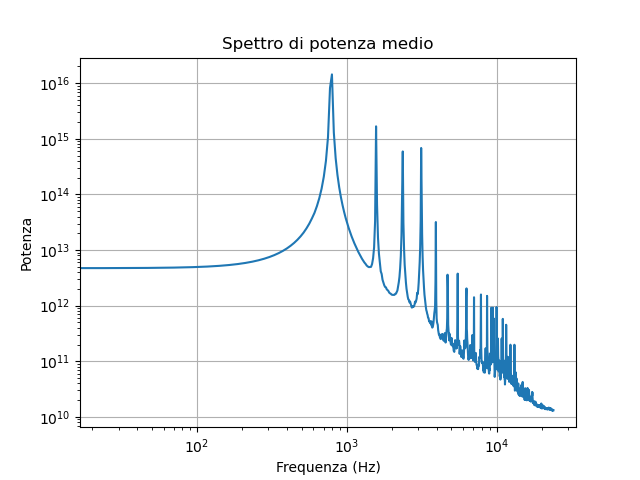

In [ ]:
#visualizzo lo spettro di potenza medio
frequencies = np.fft.rfftfreq(segment_windowed.shape[0], d=1/rate)
plt.figure()
plt.loglog(frequencies, average_power_spectrum)
plt.title('Spettro di potenza medio')
plt.xlabel('Frequenza (Hz)')
plt.ylabel('Potenza')
plt.grid()
plt.show()  

prominence =  1000000000000 , altezza =  100000000000
Frequenza fondamentale: 796.875 Hz


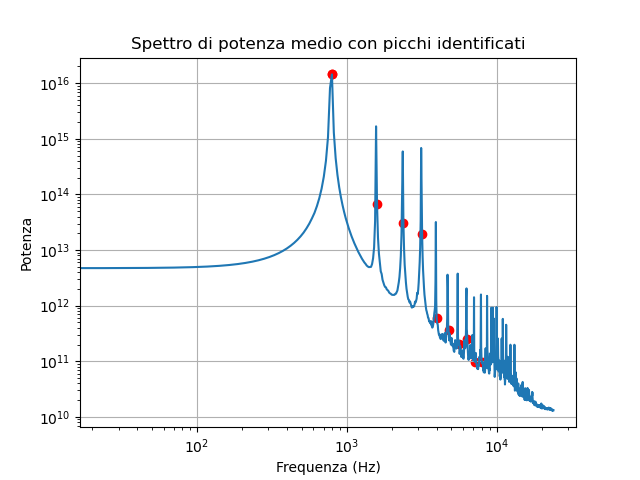

In [ ]:
# facciamo finta che il primo picco è la frequenza fondamentale (per vedere che dopo troviamo vagamente quelli corretti)
# identifichiamo i picchi per la frequenza fondamentale e le armoniche
from scipy.signal import find_peaks

prom, altezza, distanza = 0, 0, 0

if average_power_spectrum[0] < 10**11:
    altezza = 10**11
    prom = 10**11
    distanza = 10
if average_power_spectrum[0] < 10**14 and average_power_spectrum[0] >= 10**11:
    altezza = 10**12
    prom = 10**14
    distanza = 10
if average_power_spectrum[0] < 10**14 and average_power_spectrum[0] >= 10**13:
    altezza = 10**12
    prom = 10**12
    distanza = 10
else:
    altezza = 10**11
    prom = 10**12
    distanza = 10

print('prominence = ', prom, ', altezza = ', altezza)

from scipy.signal import find_peaks
peaks, _ = find_peaks(average_power_spectrum, prominence= prom, height=altezza, distance=distanza)

fundamental_freq = frequencies[peaks[0]]
print('Frequenza fondamentale:', fundamental_freq, 'Hz')

# Ora troviamo le successive armoniche, che dovrebbero essere multipli interi della frequenza fondamentale (entro una tolleranza)
tolerance = 100  # in Hz
harmonics = []
for i in range(1, 11):  # cerchiamo fino alla decima armonica
    target_freq = i * fundamental_freq
    # Troviamo il picco più vicino a target_freq
    idx = np.argmin(np.abs(frequencies - target_freq))
    if np.abs(frequencies[idx] - target_freq) < tolerance:
        harmonics.append(frequencies[idx])

#segnamole sul grafico
plt.figure()
plt.loglog(frequencies, average_power_spectrum)
plt.scatter([fundamental_freq] + harmonics, [average_power_spectrum[np.argmin(np.abs(frequencies - fundamental_freq))]] + [average_power_spectrum[np.argmin(np.abs(frequencies - h))] for h in harmonics], color='red')
plt.title('Spettro di potenza medio con picchi identificati')
plt.xlabel('Frequenza (Hz)')
plt.ylabel('Potenza')
plt.grid()
plt.show()



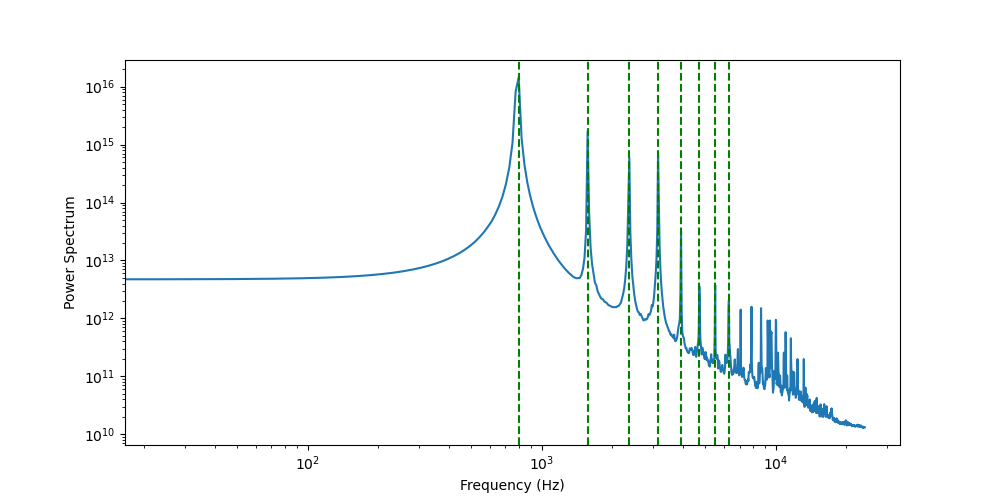

In [ ]:
# identifichiamo i picchi per la frequenza fondamentale e le armoniche
# potrebbe essere che la frequenza fondamentale non sia il picco più alto, quindi dobbiamo cercare i picchi e poi identificare la frequenza fondamentale in base alla distanza tra i picchi
from scipy.signal import find_peaks
peaks, _ = find_peaks(average_power_spectrum, prominence= prom, height=altezza, distance=distanza)

#inserisco una tolleranza per identificare la frequenza fondamentale, in modo da escludere picchi che sono troppo vicini tra loro
#controllo: se frequenza bassa tolleranza sono 50 Hz, altrimenti 100 Hz
if frequenza_preventiva < 500:
    tolerance = 20
else:
    tolerance = 100 # in Hz

picchi_freq = []
for peak in peaks:
    freq = frequencies[peak]
    if all(abs(freq - f) > tolerance for f in picchi_freq):
        picchi_freq.append(freq)

    freq_max = frequencies[np.argmax(average_power_spectrum)]

# evidenziamo i primi 6 picchi sul grafico
plt.figure(figsize=(10, 5))
plt.loglog(frequencies, average_power_spectrum)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectrum")
for f in picchi_freq[:8]:  
    plt.axvline(f, color='g', linestyle='--')
plt.show()

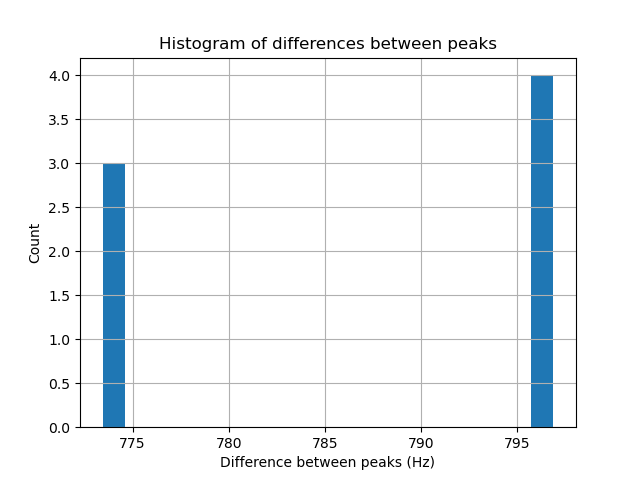

In [ ]:
# calcoliamo la differenza tra una armonica e la successiva dei 6 picchi, in modo da identificare la frequenza fondamentale come il massimo comun divisore tra i picchi
diffs = np.diff(picchi_freq[:8])
plt.figure()
plt.hist(diffs, bins=20)
plt.xlabel('Difference between peaks (Hz)')
plt.ylabel('Count')
plt.title('Histogram of differences between peaks')
plt.grid()
plt.show()

In [ ]:
# maschera per prendere solo le differenze giuste (cioè quelle del bin più elevato)
counts, bin_edges = np.histogram(diffs, bins=20) 

# Indice del bin con più occorrenze
idx_max = np.argmax(counts)
print(" Bin con più occorrenze:", idx_max, "con", counts[idx_max], "occurrences")

soglia_min = bin_edges[idx_max]
soglia_max = bin_edges[idx_max + 1]
differenze_nel_picco = diffs[(diffs >= soglia_min) & (diffs <= soglia_max)]

# La tua frequenza fondamentale stimata
f0_stimata = np.mean(differenze_nel_picco)

print('Soglia minima:', soglia_min, 'Hz')
print('Soglia massima:', soglia_max, 'Hz')

print('Frequenza fondamentale stimata:', f0_stimata, 'Hz')

 Bin con più occorrenze: 19 con 4 occurrences
Soglia minima: 795.703125 Hz
Soglia massima: 796.875 Hz
Frequenza fondamentale stimata: 796.875 Hz
